Degree: 1 Test Error: 0.183
Degree: 4 Test Error: 0.005
Degree: 15 Test Error: 0.307


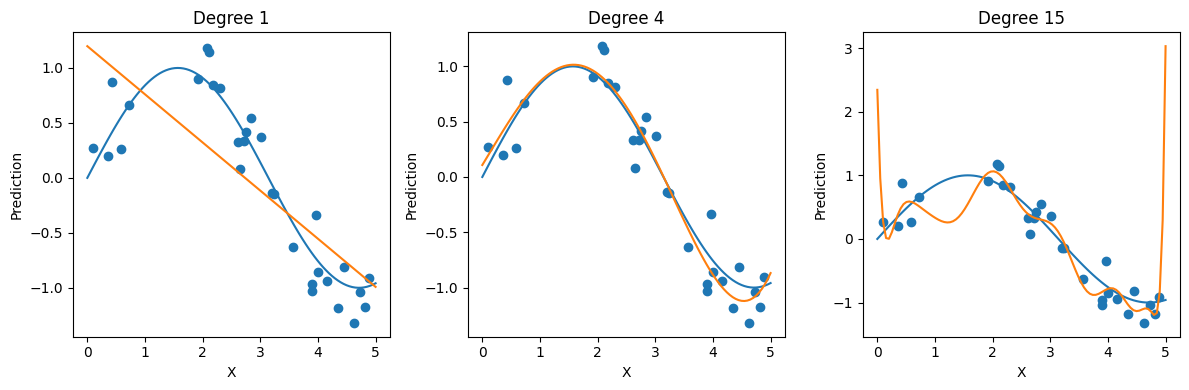

In [13]:


import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

from sklearn.metrics import mean_squared_error


# Create data
np.random.seed(0)

X = np.sort(5 * np.random.rand(30, 1), axis=0)

# True function
y = np.sin(X).ravel()

# Add noise
y = y + np.random.normal(0, 0.2, size=len(y))


# Test data
X_test = np.linspace(0, 5, 100).reshape(-1,1)
y_true = np.sin(X_test)


degrees = [1, 4, 15]


plt.figure(figsize=(12,4))


for i, degree in enumerate(degrees):

    # Polynomial model
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )


    # Train
    model.fit(X, y)


    # Prediction
    y_pred = model.predict(X_test)


    # Error
    mse = mean_squared_error(y_true, y_pred)


    print(
        "Degree:",
        degree,
        "Test Error:",
        round(mse,3)
    )


    # Plot
    plt.subplot(1,3,i+1)

    plt.scatter(X, y)

    plt.plot(
        X_test,
        y_true
    )

    plt.plot(
        X_test,
        y_pred
    )

    plt.title(
        f"Degree {degree}"
    )

    plt.xlabel("X")
    plt.ylabel("Prediction")


plt.tight_layout()

plt.show()

## 1. Understanding Bias and Variance with Synthetic Data


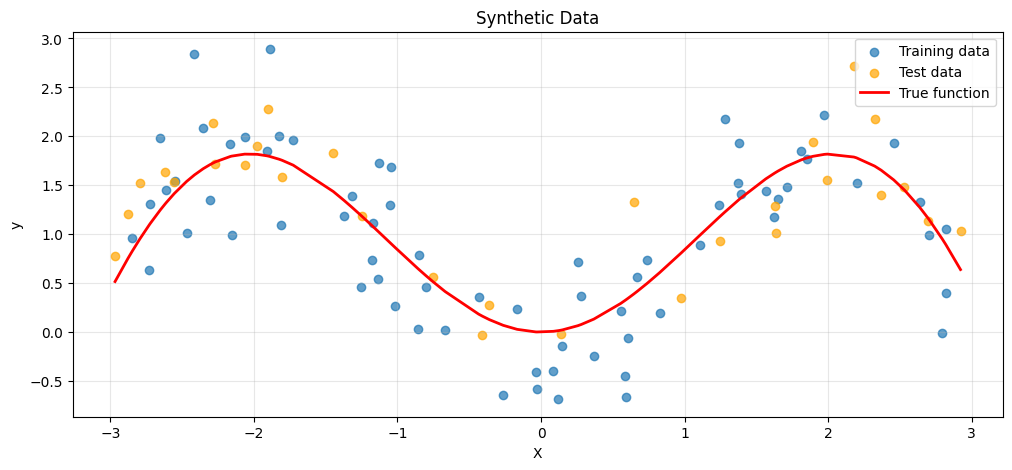

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
def generate_data(n_samples=100, noise=0.5):
    X = np.random.uniform(-3, 3, n_samples)
    # True function: f(x) = x * sin(x) 
    y_true = X * np.sin(X)
    y = y_true + np.random.normal(0, noise, n_samples)
    return X.reshape(-1, 1), y, y_true

X, y, y_true = generate_data(n_samples=100, noise=0.5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Visualize the data
plt.figure(figsize=(12, 5))
plt.scatter(X_train, y_train, alpha=0.7, label='Training data')
plt.scatter(X_test, y_test, alpha=0.7, label='Test data', color='orange')
plt.plot(np.sort(X.flatten()), np.sort(X.flatten()) * np.sin(np.sort(X.flatten())), 
         color='red', label='True function', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Demonstrating Bias-Variance Tradeoff with Polynomial Models


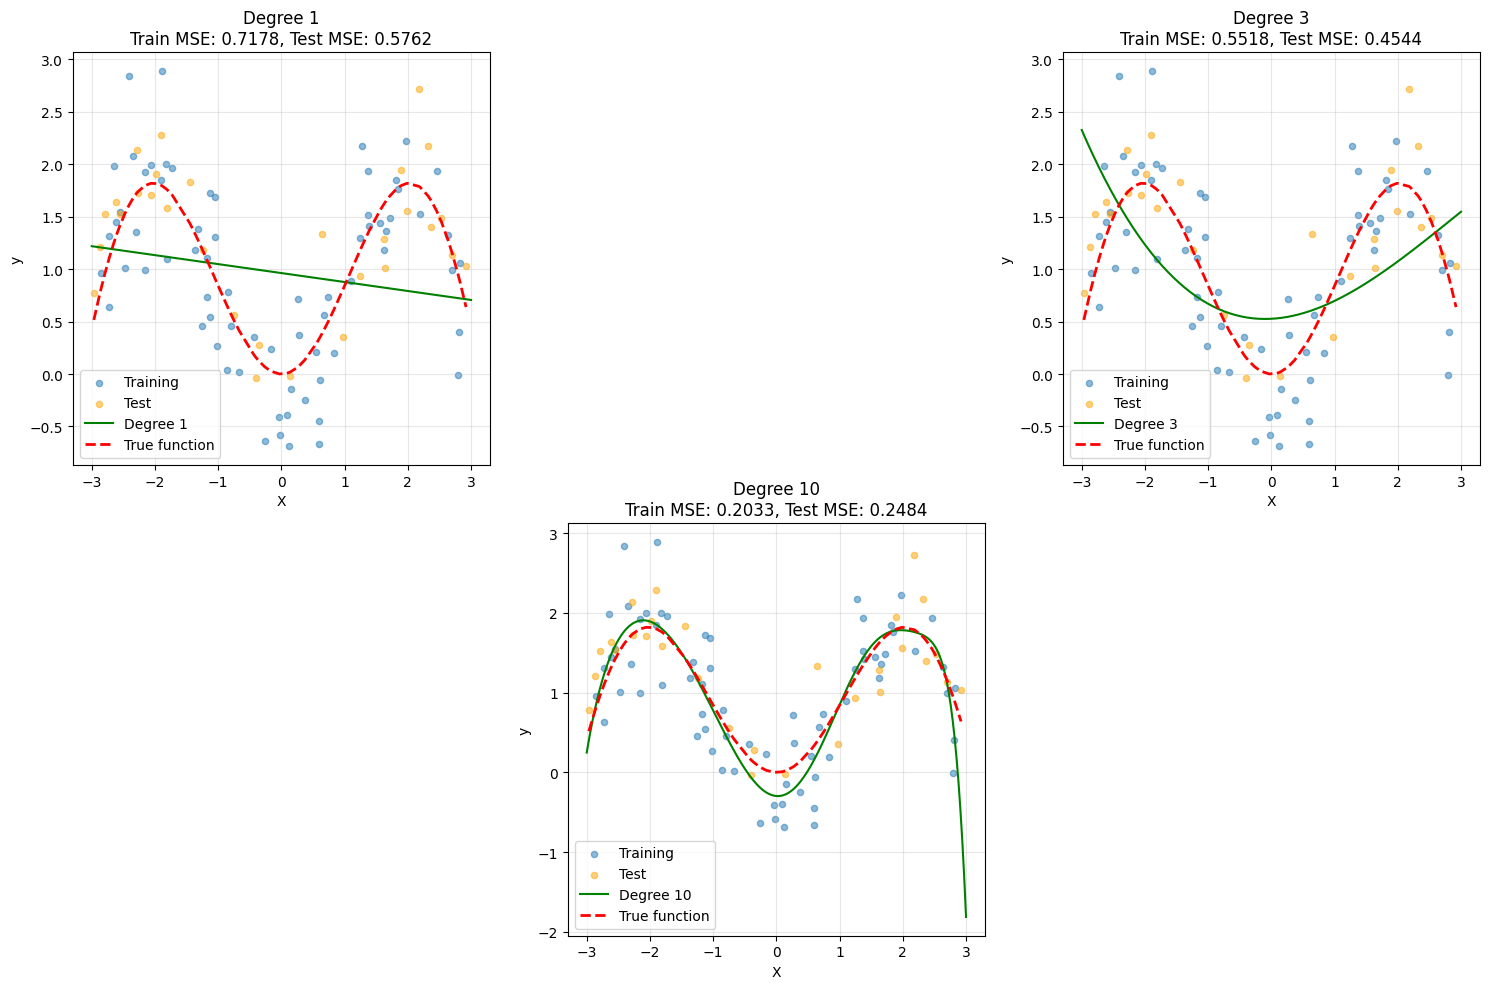

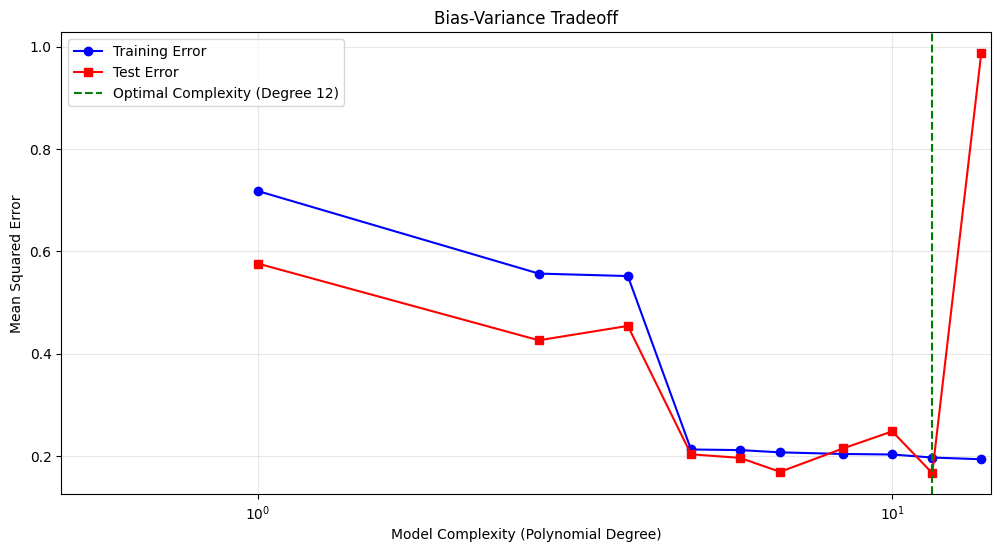

Optimal polynomial degree: 12
Minimum test error: 0.1669


In [15]:
# Function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    return train_mse, test_mse, y_train_pred, y_test_pred

# Test different polynomial degrees
degrees = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15]
train_errors = []
test_errors = []
models = []

plt.figure(figsize=(15, 10))

for i, degree in enumerate(degrees):
    # Create polynomial regression model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    train_mse, test_mse, y_train_pred, y_test_pred = evaluate_model(
        model, X_train, X_test, y_train, y_test
    )
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    models.append(model)
    
    # Plot predictions for some degrees
    if degree in [1, 3, 10]:
        plt.subplot(2, 3, [1, 3, 5, 2, 4, 6][i//2] if i < 6 else 5)
        X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
        y_grid_pred = model.predict(X_grid)
        
        plt.scatter(X_train, y_train, alpha=0.5, label='Training', s=20)
        plt.scatter(X_test, y_test, alpha=0.5, label='Test', s=20, color='orange')
        plt.plot(X_grid, y_grid_pred, color='green', label=f'Degree {degree}')
        plt.plot(np.sort(X.flatten()), np.sort(X.flatten()) * np.sin(np.sort(X.flatten())), 
                 color='red', label='True function', linewidth=2, linestyle='--')
        plt.xlabel('X')
        plt.ylabel('y')
        plt.title(f'Degree {degree}\nTrain MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}')
        plt.legend()
        plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot bias-variance tradeoff
plt.figure(figsize=(12, 6))
plt.plot(degrees, train_errors, 'b-', label='Training Error', marker='o')
plt.plot(degrees, test_errors, 'r-', label='Test Error', marker='s')
plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('Mean Squared Error')
plt.title('Bias-Variance Tradeoff')
plt.axvline(x=degrees[np.argmin(test_errors)], color='green', linestyle='--', 
            label=f'Optimal Complexity (Degree {degrees[np.argmin(test_errors)]})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('symlog')
plt.show()

print(f"Optimal polynomial degree: {degrees[np.argmin(test_errors)]}")
print(f"Minimum test error: {min(test_errors):.4f}")

## 3. Measuring Bias and Variance Separately (Bootstrap Method)

In [16]:
def bootstrap_bias_variance(model_class, X, y, n_bootstrap=100, **model_params):
    """
    Estimate bias and variance using bootstrap sampling
    """
    n_samples = len(X)
    all_predictions = []
    
    for _ in range(n_bootstrap):
        # Bootstrap sample
        indices = np.random.choice(n_samples, n_samples, replace=True)
        X_boot = X[indices]
        y_boot = y[indices]
        
        # Fit model
        model = model_class(**model_params)
        model.fit(X_boot, y_boot)
        
        # Predict on all data
        y_pred = model.predict(X)
        all_predictions.append(y_pred)
    
    all_predictions = np.array(all_predictions)
    
    # Calculate bias, variance, and total error
    mean_prediction = np.mean(all_predictions, axis=0)
    bias_squared = np.mean((mean_prediction - y.flatten()) ** 2)
    variance = np.mean(np.var(all_predictions, axis=0))
    irreducible_error = np.var(y.flatten())  # irreducible error
    total_error = bias_squared + variance + irreducible_error
    
    return bias_squared, variance, total_error

# Compare different models
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Define the models more clearly
models_to_compare = []

# Linear model
models_to_compare.append(('Linear', LinearRegression, {}, False, None))

# Polynomial models - specify degree directly
poly_degrees = [3, 10]
for degree in poly_degrees:
    models_to_compare.append(
        (f'Polynomial (degree {degree})', LinearRegression, {}, True, degree)
    )

# Decision tree models
models_to_compare.append(('Decision Tree (max_depth=3)', DecisionTreeRegressor, 
                          {'max_depth': 3}, False, None))
models_to_compare.append(('Decision Tree (max_depth=10)', DecisionTreeRegressor, 
                          {'max_depth': 10}, False, None))
models_to_compare.append(('Decision Tree (max_depth=None)', DecisionTreeRegressor, 
                          {}, False, None))

results = []

for name, model_class, params, is_polynomial, degree in models_to_compare:
    print(f"Processing: {name}...")
    
    if is_polynomial and degree is not None:
        # Transform features for polynomial
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_transformed = poly.fit_transform(X)
        bias_sq, variance, total = bootstrap_bias_variance(
            model_class, X_transformed, y, n_bootstrap=50, **params
        )
    else:
        # Use original features
        bias_sq, variance, total = bootstrap_bias_variance(
            model_class, X, y, n_bootstrap=50, **params
        )
    
    results.append({
        'Model': name,
        'Bias²': bias_sq,
        'Variance': variance,
        'Total Error': total
    })

# Display results
print("\n" + "="*80)
print("BIAS-VARIANCE DECOMPOSITION FOR DIFFERENT MODELS")
print("="*80)
print(f"{'Model':<30} {'Bias²':<15} {'Variance':<15} {'Total Error':<15}")
print("-"*80)
for r in results:
    print(f"{r['Model']:<30} {r['Bias²']:.4f}        {r['Variance']:.4f}        {r['Total Error']:.4f}")
print("="*80)

Processing: Linear...
Processing: Polynomial (degree 3)...
Processing: Polynomial (degree 10)...
Processing: Decision Tree (max_depth=3)...
Processing: Decision Tree (max_depth=10)...
Processing: Decision Tree (max_depth=None)...

BIAS-VARIANCE DECOMPOSITION FOR DIFFERENT MODELS
Model                          Bias²           Variance        Total Error    
--------------------------------------------------------------------------------
Linear                         0.6615        0.0136        1.3477
Polynomial (degree 3)          0.5132        0.0305        1.2164
Polynomial (degree 10)         0.1873        0.0257        0.8855
Decision Tree (max_depth=3)    0.1623        0.0705        0.9053
Decision Tree (max_depth=10)   0.0400        0.1008        0.8134
Decision Tree (max_depth=None) 0.0396        0.1063        0.8184


## 4. Regularization to Control Bias-Variance (Ridge Regression)

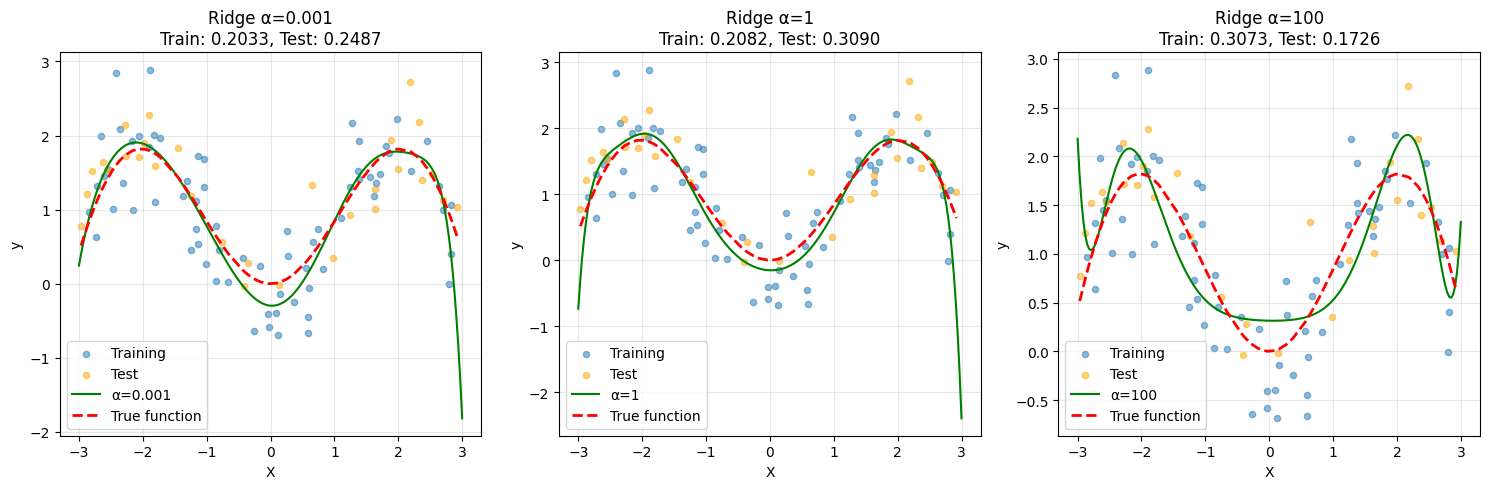

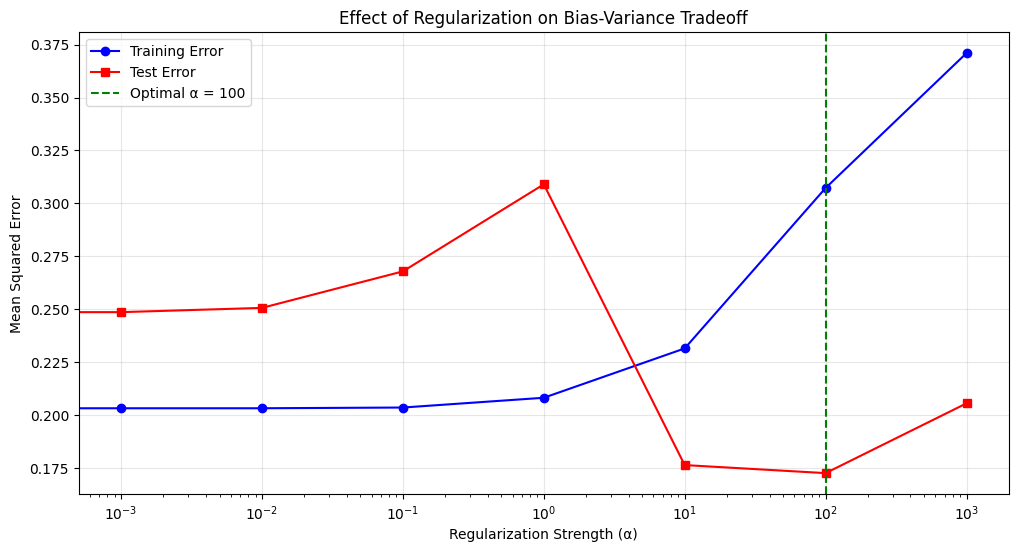

Optimal regularization alpha: 100
Minimum test error: 0.1726


In [17]:
# Demonstrate how regularization affects bias-variance tradeoff
alphas = [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_errors_ridge = []
test_errors_ridge = []

plt.figure(figsize=(15, 5))

for i, alpha in enumerate(alphas):
    # Ridge regression with polynomial features
    model = make_pipeline(
        PolynomialFeatures(degree=10), 
        Ridge(alpha=alpha)
    )
    train_mse, test_mse, _, _ = evaluate_model(
        model, X_train, X_test, y_train, y_test
    )
    train_errors_ridge.append(train_mse)
    test_errors_ridge.append(test_mse)
    
    # Plot for some alphas
    if alpha in [0.001, 1, 100]:
        plt.subplot(1, 3, [1, 2, 3][i//3])
        X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
        y_grid_pred = model.predict(X_grid)
        
        plt.scatter(X_train, y_train, alpha=0.5, label='Training', s=20)
        plt.scatter(X_test, y_test, alpha=0.5, label='Test', s=20, color='orange')
        plt.plot(X_grid, y_grid_pred, color='green', label=f'α={alpha}')
        plt.plot(np.sort(X.flatten()), np.sort(X.flatten()) * np.sin(np.sort(X.flatten())), 
                 color='red', label='True function', linewidth=2, linestyle='--')
        plt.xlabel('X')
        plt.ylabel('y')
        plt.title(f'Ridge α={alpha}\nTrain: {train_mse:.4f}, Test: {test_mse:.4f}')
        plt.legend()
        plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot regularization effect
plt.figure(figsize=(12, 6))
plt.semilogx(alphas, train_errors_ridge, 'b-', label='Training Error', marker='o')
plt.semilogx(alphas, test_errors_ridge, 'r-', label='Test Error', marker='s')
plt.xlabel('Regularization Strength (α)')
plt.ylabel('Mean Squared Error')
plt.title('Effect of Regularization on Bias-Variance Tradeoff')
plt.axvline(x=alphas[np.argmin(test_errors_ridge)], color='green', linestyle='--', 
            label=f'Optimal α = {alphas[np.argmin(test_errors_ridge)]}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal regularization alpha: {alphas[np.argmin(test_errors_ridge)]}")
print(f"Minimum test error: {min(test_errors_ridge):.4f}")

## 5. Learning Curves to Detect Bias/Variance Problems

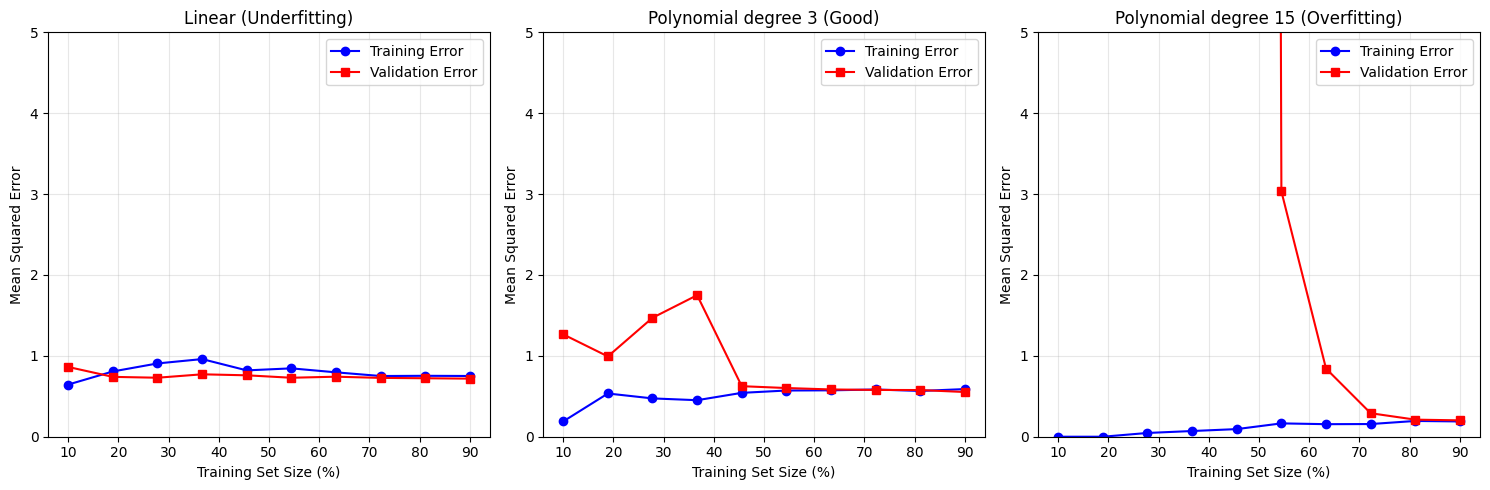

In [18]:
def plot_learning_curves(model, X, y, train_sizes=np.linspace(0.1, 0.9, 10)):
    """
    Plot learning curves to diagnose bias vs variance
    """
    train_scores = []
    val_scores = []
    
    for size in train_sizes:
        n_samples = int(size * len(X))
        X_train_sub, y_train_sub = X[:n_samples], y[:n_samples]
        
        # Train on subset
        model.fit(X_train_sub, y_train_sub)
        
        # Predict on training and validation
        y_train_pred = model.predict(X_train_sub)
        y_val_pred = model.predict(X)
        
        train_mse = mean_squared_error(y_train_sub, y_train_pred)
        val_mse = mean_squared_error(y, y_val_pred)
        
        train_scores.append(train_mse)
        val_scores.append(val_mse)
    
    return train_scores, val_scores

# Compare learning curves for different models
plt.figure(figsize=(15, 5))

models_lc = [
    ('Linear (Underfitting)', make_pipeline(PolynomialFeatures(1), LinearRegression())),
    ('Polynomial degree 3 (Good)', make_pipeline(PolynomialFeatures(3), LinearRegression())),
    ('Polynomial degree 15 (Overfitting)', make_pipeline(PolynomialFeatures(15), LinearRegression()))
]

for i, (name, model) in enumerate(models_lc):
    train_scores, val_scores = plot_learning_curves(model, X_train, y_train)
    
    plt.subplot(1, 3, i+1)
    train_sizes_pct = np.linspace(0.1, 0.9, 10) * 100
    plt.plot(train_sizes_pct, train_scores, 'b-', label='Training Error', marker='o')
    plt.plot(train_sizes_pct, val_scores, 'r-', label='Validation Error', marker='s')
    plt.xlabel('Training Set Size (%)')
    plt.ylabel('Mean Squared Error')
    plt.title(name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 5)

plt.tight_layout()
plt.show()

## 6. Diagnosing and Fixing Bias-Variance Issues

In [19]:
def diagnose_bias_variance(model, X_train, X_test, y_train, y_test):
    """
    Diagnose whether model has high bias or high variance
    """
    # Fit model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    # Diagnosis
    print(f"Training MSE: {train_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Training R²: {train_score:.4f}")
    print(f"Test R²: {test_score:.4f}")
    
    if train_mse > 1.0 and test_mse > 1.0:
        diagnosis = "High Bias (Underfitting) - Both training and test errors are high"
    elif train_mse < 0.5 and test_mse > 1.0:
        diagnosis = "High Variance (Overfitting) - Training error low but test error high"
    elif train_mse < 0.5 and test_mse < 0.5:
        diagnosis = "Good Fit - Both errors are low"
    else:
        diagnosis = "Moderate - May need more data or regularization"
    
    print(f"Diagnosis: {diagnosis}")
    return diagnosis

# Test with different models
print("=" * 60)
print("Model 1: Simple Linear Regression")
model_linear = make_pipeline(PolynomialFeatures(1), LinearRegression())
diagnose_bias_variance(model_linear, X_train, X_test, y_train, y_test)

print("\n" + "=" * 60)
print("Model 2: Polynomial Degree 3")
model_poly3 = make_pipeline(PolynomialFeatures(3), LinearRegression())
diagnose_bias_variance(model_poly3, X_train, X_test, y_train, y_test)

print("\n" + "=" * 60)
print("Model 3: Polynomial Degree 15 (Overfitting)")
model_poly15 = make_pipeline(PolynomialFeatures(15), LinearRegression())
diagnose_bias_variance(model_poly15, X_train, X_test, y_train, y_test)

print("\n" + "=" * 60)
print("Model 4: Ridge Regression (Regularized)")
model_ridge = make_pipeline(PolynomialFeatures(15), Ridge(alpha=1.0))
diagnose_bias_variance(model_ridge, X_train, X_test, y_train, y_test)

Model 1: Simple Linear Regression
Training MSE: 0.7178
Test MSE: 0.5762
Training R²: 0.0275
Test R²: -0.3444
Diagnosis: Moderate - May need more data or regularization

Model 2: Polynomial Degree 3
Training MSE: 0.5518
Test MSE: 0.4544
Training R²: 0.2525
Test R²: -0.0602
Diagnosis: Moderate - May need more data or regularization

Model 3: Polynomial Degree 15 (Overfitting)
Training MSE: 0.1939
Test MSE: 0.9872
Training R²: 0.7373
Test R²: -1.3036
Diagnosis: Moderate - May need more data or regularization

Model 4: Ridge Regression (Regularized)
Training MSE: 0.1988
Test MSE: 0.4987
Training R²: 0.7306
Test R²: -0.1637
Diagnosis: Good Fit - Both errors are low


'Good Fit - Both errors are low'

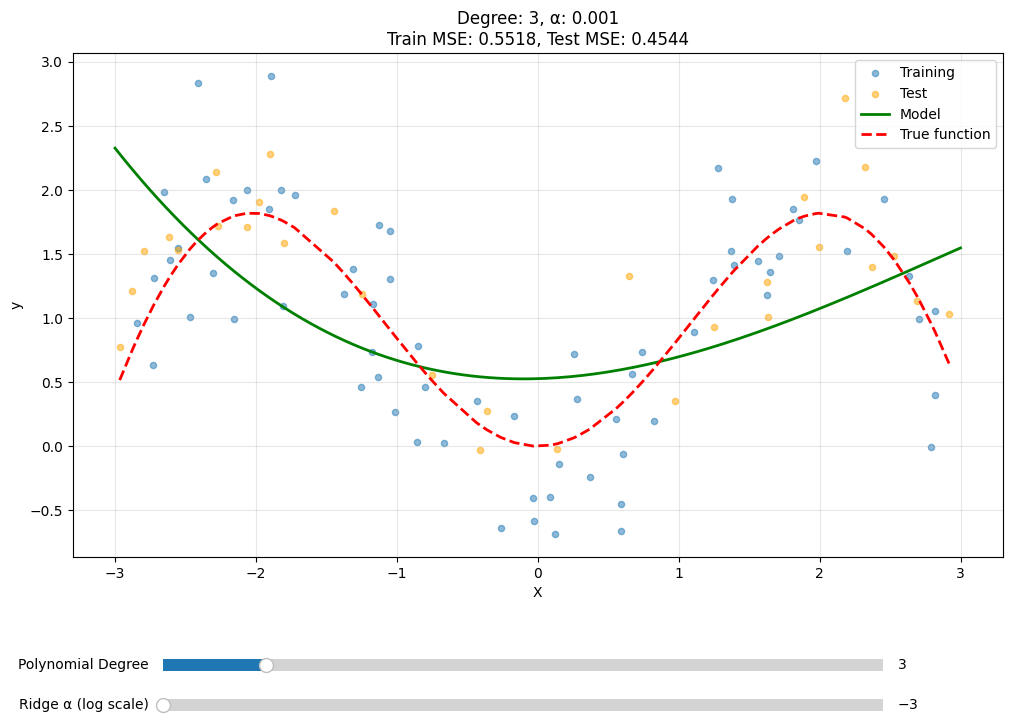

In [20]:
from matplotlib.widgets import Slider

def interactive_bias_variance():
    """
    Interactive demonstration of bias-variance tradeoff
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    plt.subplots_adjust(bottom=0.25)
    
    # Initial parameters
    degree = 3
    alpha = 0
    
    # Create sliders
    ax_degree = plt.axes([0.2, 0.1, 0.6, 0.03])
    ax_alpha = plt.axes([0.2, 0.05, 0.6, 0.03])
    
    slider_degree = Slider(ax_degree, 'Polynomial Degree', 1, 15, valinit=degree, valstep=1)
    slider_alpha = Slider(ax_alpha, 'Ridge α (log scale)', -3, 3, valinit=np.log10(alpha+0.001))
    
    def update(val):
        ax.clear()
        degree = int(slider_degree.val)
        alpha = 10 ** slider_alpha.val
        
        # Create model
        model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=alpha))
        model.fit(X_train, y_train)
        
        # Predict
        X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
        y_grid_pred = model.predict(X_grid)
        
        # Plot
        ax.scatter(X_train, y_train, alpha=0.5, label='Training', s=20)
        ax.scatter(X_test, y_test, alpha=0.5, label='Test', s=20, color='orange')
        ax.plot(X_grid, y_grid_pred, color='green', linewidth=2, label='Model')
        ax.plot(np.sort(X.flatten()), np.sort(X.flatten()) * np.sin(np.sort(X.flatten())), 
                 color='red', label='True function', linewidth=2, linestyle='--')
        
        # Calculate errors
        train_mse = mean_squared_error(y_train, model.predict(X_train))
        test_mse = mean_squared_error(y_test, model.predict(X_test))
        
        ax.set_xlabel('X')
        ax.set_ylabel('y')
        ax.set_title(f'Degree: {degree}, α: {alpha:.3f}\nTrain MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.canvas.draw_idle()
    
    slider_degree.on_changed(update)
    slider_alpha.on_changed(update)
    update(None)
    plt.show()


interactive_bias_variance()